# Fitting Donor-Acceptor FLIM Data

The donor **and** acceptor fluorescence decay profiles is to be described and fitted for determination of the resonance energy transfer rate.

$$\frac{d[D^*]}{dt} = - \frac{d[D]}{dt} = -(k_{f}^{D} + k_{r}^{DA})D^* + \phi^{D} \text{IRF}(t)$$

$$\frac{d[A^*]}{dt} = - \frac{d[A]}{dt} = -k_{f}^{A} A^* + k_{r}^{DA})D^* + \lambda^{DA} \bigg[ \frac{d[D^*]}{dt} (t) \bigg] + \phi^{A} \text{IRF}(t)$$

In the system of differential equations, the change in the population of excited and ground state donor and acceptor molecules is described.

Both molecules are assumed to decay from their excited state, $D^*$ and $A^*$, with the rate constants $k_{f}^{D}$ and $k_{f}^{A}$, respectively (i.e. monoexponentially). The energy transfer takes places between the excited donor molecule population, $[D^*]$, and thus excited molecules from the ground state acceptor population, $[A]$, with the rate constant $k_{r}^{DA}$ (superscript denotes direction of energy transfer from left to right). The ground state acceptor population is not included in the description of the acceptor population, because it is assumed that $[A] \gg [D^*]$.

The donor is excited via laser excitation, which is described by the instrument response function of the measurement setup, $\text{IRF}(t)$. It can be either approximted as a Gaussian or fitted to measured data and fitted to a multi-component Gaussian function. For testing and simulation purposes, $\tetx{IRF}(t)$ is modeled as
Gaussian function

$$\text{IRF}(t) = \frac{1}{\sigma \sqrt{2 \pi}} e^{-\frac{1}{2} \big( \frac{t - \mu_{i}}{\sigma} \big)^{2}}$$

with the $\text{FWHM}$ of the $\text{IRF}$ as $2 \sqrt{2 \ ln 2} \ \sigma \approx 2.3548 \sigma$. 

The purpose of the model is to include two main error inherent to simultanous donor-acceptor measurement, either via FLIM or intensity-based: 1.) excitation of the acceptor by the laser at donor excitation wavelength ($\phi^{A}$) and 2.) bleed-through of the donor signal into the acceptor detection channel ($\lambda^{DA}$).
The cross-excitation is modeled as a fractional contribution of $\text{IRF}(t)$ to the excitation of $[A]$. This is determined by a sample, where only the acceptor molecule is expressed and it is excited at the donor wavelength. The spectral bleed-through, $\lambda^{DA}$, of the donor signal into the acceptor detection channel is modeled as a fractional addition of the current donor signal at $t$ to the acceptor signal at $t$ weighted by a constant. 


In [243]:
%reset -f
# Importing required modules and setting up matplotlib
import math
from numba import jit
from scipy.integrate import odeint
import scipy.optimize as optimize
import numpy as np
import matplotlib.pyplot as plt


from matplotlib import rcParams
%config InlineBackend.figure_format='retina'
rcParams['figure.figsize'] = (16, 12)
rcParams['legend.fontsize']  = 16
rcParams['axes.labelsize'] = 16

# Import PTU reading / decoding functions
import pq_decoding_functions

In [309]:

def da_flim_ODE(y, t, pars):
    
    kf_D, k_r, kf_A, sigma, mu = pars
    t = t
        
    
    dD1 = -(kf_D)*y[1] - (k_r)*y[1] + gauss_laser(t, mu, sigma)*y[0]
    dD0 = -dD1
    dA1 = -(kf_A)*y[3] + (k_r)*y[1]
    dA0 = -dA1
    return([dD0, dD1, dA0, dA1])



def eval_ode(t, pars, fitting = False):
    y0 = pars[0:4]
    sim_params = pars[4:9]
    offset = pars[9]
    acceptor_shift = pars[10]
    
    sol = odeint(da_flim_ODE, y0, t, hmax = dt, args = (sim_params, ))
    
    # Displacing excited acceptor signal to simulate difference
    # in photon arrival time, e.g. due to different cable
    # lenghts to acceptor signal detector.
    # np.roll() wraps array around itself.
    sol[:, 3] = np.roll(sol[:, 3], int(acceptor_shift))
    
    # fitting: bool indicates whether curve fitting is performed or data is simulated
    # When data is fitted, we don't need to add noise, but want to add an offset.
    # When data is simulated, addPoissonNoise() adds intensity-weighted Poisson noise and
    # an additional Poisson noise array to each decay with lambda = offset
    if(fitting):
        sol += offset
    else:
        sol = addPoissonNoise(sol, offset)
    
    return(sol)

@jit(nopython = True)
def gauss_laser(t, mu, sigma):
    out = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5 * ((t - mu) / sigma)**2)
    return(float(out))



def addPoissonNoise(decay, offset):
    decay[:, 1] = np.random.poisson(decay[:, 1], len(decay[:, 1])) # Only adding to excited donor decay at index 1
    decay[:, 1] += np.random.poisson(offset, len(decay[:, 1]))
    decay[:, 3] = np.random.poisson(decay[:, 3], len(decay[:, 3])) # Only adding to excited donor decay at index 1
    decay[:, 3] += np.random.poisson(offset, len(decay[:, 3])) # Only adding to excited acceptor decay at index 3
    return(decay)



def estimateBackground(data):
    '''
        Calculates median of last 7 % of data.
        Used for weighting of 0 values; would otherwise lead to division by 0. Instead,
        the weight for the median background value is used for residue weighting.
    '''
    index_right_cutoff = int(math.floor(len(data) * 0.97))
    index_left_cutoff = int(math.floor(len(data) * 0.90))
    background = np.median(data[index_left_cutoff : index_right_cutoff])
    
    return(background)


def calculateWeights(data):
    weights = np.zeros_like(data)
    weights = 1.0/np.sqrt(data, where = (data != 0))
    weights[np.where(data == 0)] = 1.0/np.sqrt(estimateBackground(data))

    return(weights)


def residuals(pars, t, data, weighted = True):
    model = eval_ode(t, pars, fitting = True)

    if(weighted == True):
        
        resids_donor = ((data[:, 1] - model[:, 1])**2) * calculateWeights(data[:, 1])
        resids_acceptor = ((data[:, 3] - model[:, 3])**2) * calculateWeights(data[:, 3])
        
    else:
        resids_donor = (model[:, 1] - data[:, 1])**2 # We only have D_1 and A_1, so we only calculate residuals for them
        resids_acceptor = (model[:, 3] - data[:, 3])**2
    
    resids = np.hstack((resids_donor, resids_acceptor))
   
    return(resids)


## Get left flank of decays for time offset determination --> required for proper time offset guessing
## Returns index at which left decay flank
def get_decay_flank(decay):
    first_derivative = np.diff(decay, n = 1)
    max_rise = np.where(first_derivative == max(first_derivative))[0][0]
    
    return(max_rise)



# Manually calculating chi-squared for donor and acceptor each
def calculate_chi_squred(data, fit, number_fit_parameters = 11):
    donor_resids = np.sum(
        (data[:, 1] - fit[:, 1])**2 / fit[:, 1]
    )
    acceptor_resids = np.sum(
        (data[:, 3] - fit[:, 3])**2 / fit[:, 3]
    )
    
    red_chi_donor = donor_resids / (len(data[:, 1]) - number_fit_parameters - 1)
    red_chi_acceptor = acceptor_resids / (len(data[:, 3]) - number_fit_parameters - 1)
    
    return([red_chi_donor, red_chi_acceptor])

In [386]:
# Setting up the simulation time axis and simulation parameters
tStart = 0
tEnd = 51000
dt = 16
tSteps = int((tEnd - tStart) / dt)
t = np.linspace(tStart, tEnd, tSteps)

sim_params = np.array((
    1500, # D(0)
    1, # D*(0)
    3000, # A(0)
    1, # A*(0)
    1/2500, #kf_D
    1/95000, #k_r
    1/1400, #kf_A
    150, #sigma
    3500, #mu
    30, #offset
    0 #acceptor_shift
))

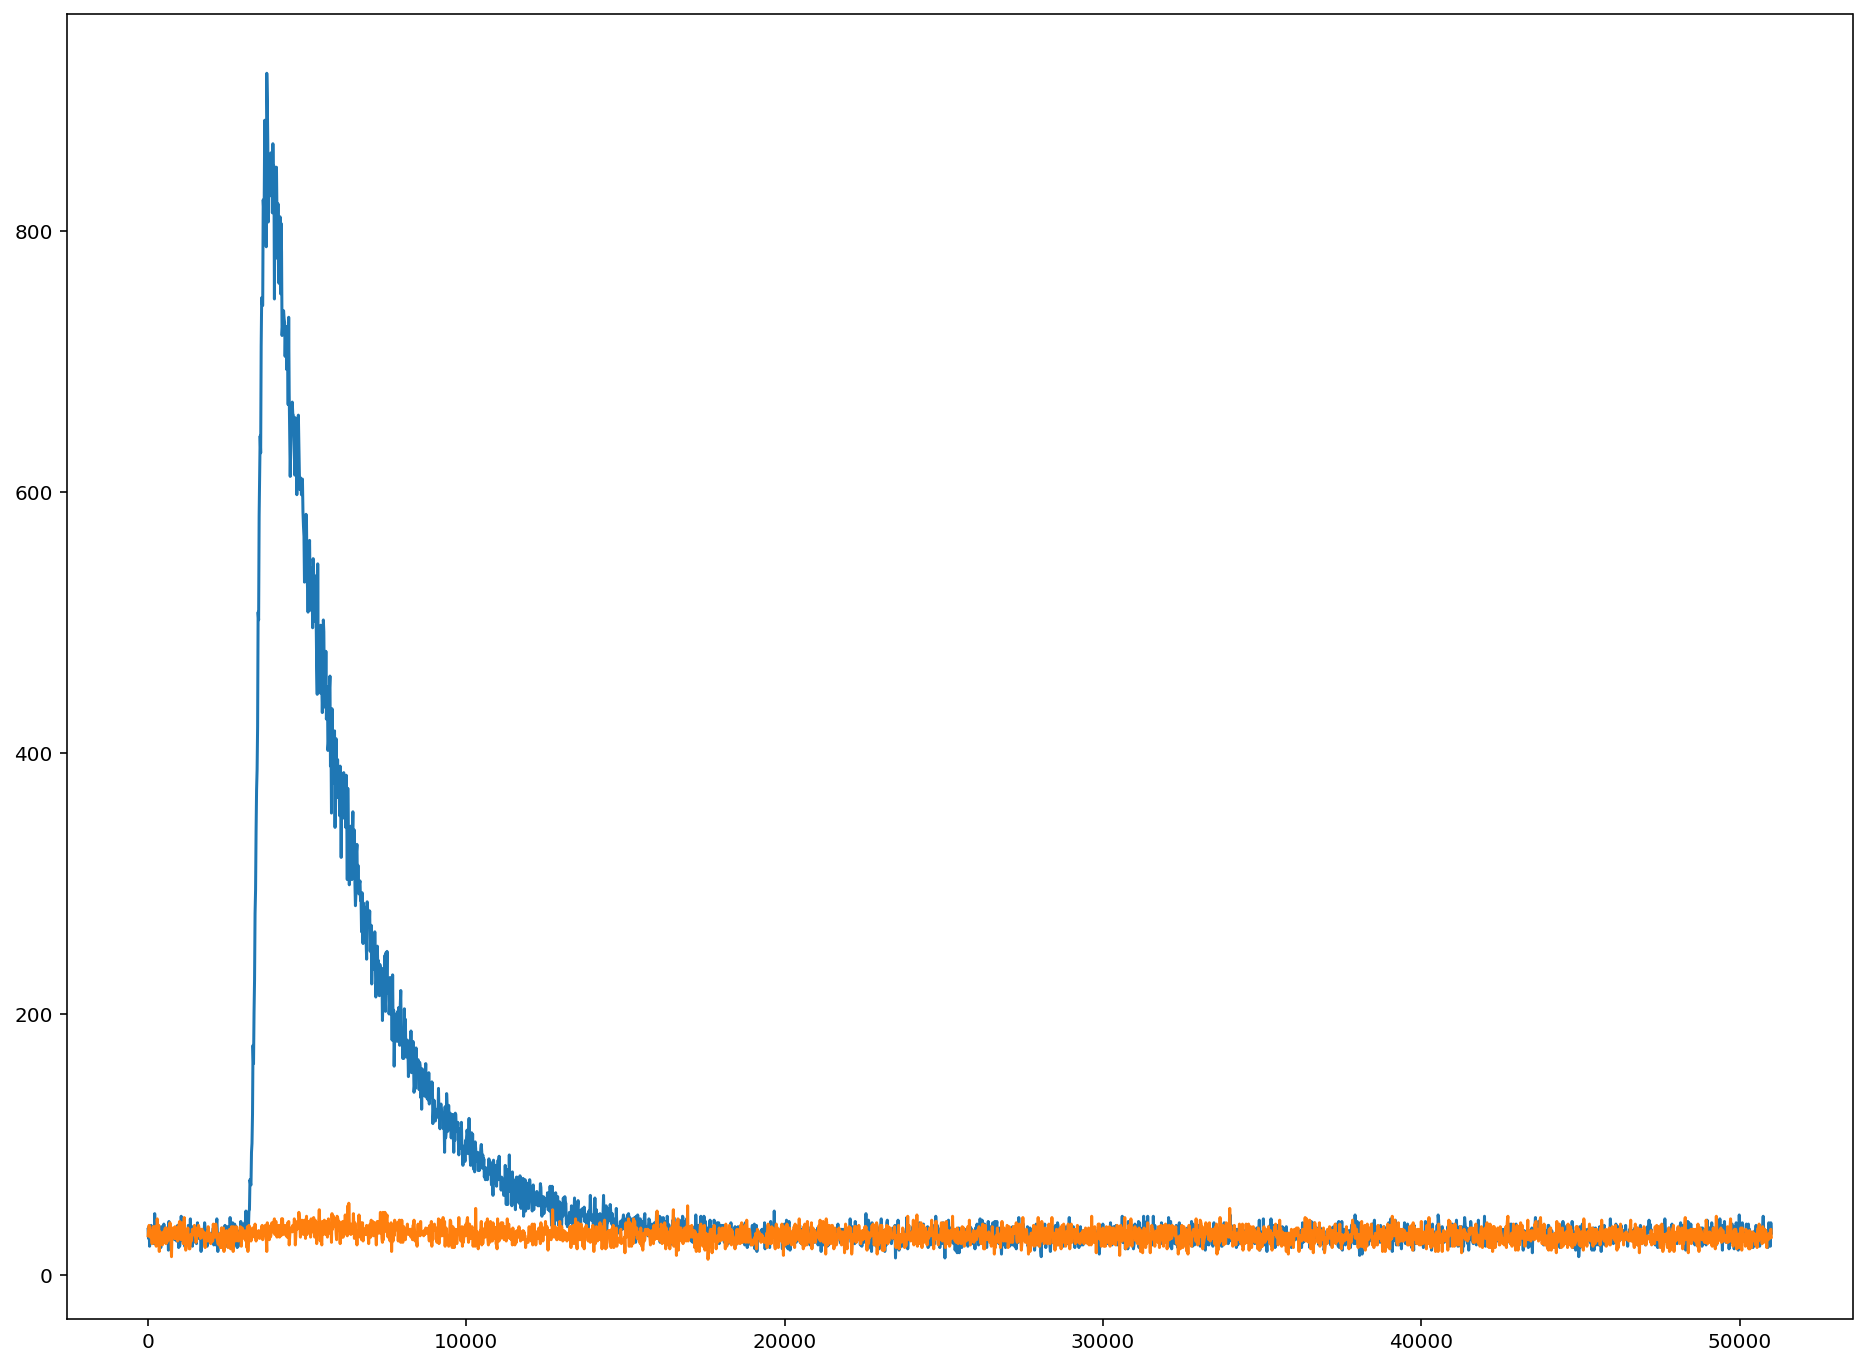

In [387]:
# Calculating example data and adding noise

sim_data = eval_ode(t, sim_params, fitting = False) # Fitting set to False, so that Poisson noise is addded


plt.plot(t, sim_data[:, 1])
plt.plot(t, sim_data[:, 3])
plt.show()

In [388]:
## Defining lmfit.Parameters object for curve fitting

guessed_mu = get_decay_flank(sim_data[:, 1])
guessed_acceptor_shift = guessed_mu - get_decay_flank(sim_data[:, 3])


# Fitting parameters for scipy.optimize + fit bounds+

para_start = (
    300, # D(0) -> Number of ground state molecules at t = 0
    0, # D*(0)
    300, # A(0)
    0, # A*(0)
    1/2550, # kf_D -> Donor decay rate/
    1/8000, # k_r -> Rate of energy transfer
    1/1420, # kf_A -> Acceptor decay rate
    100, # sigma -> Width of excitation pulse
    3500, # mu -> t-offset of excitation pulse
    10, # offset -> y-offset of decay
    -0 # acceptor_shift -> number of indices the acceptor signal is displaced in time compared to donor
)

para_names = (
    "D(0)",
    "D*(0)",
    "A(0)",
    "A*(0)",
    "kf_D",
    "k_r",
    "kf_A",
    "IRFsigma",
    "IRFmu",
    "IRFoffset",
    "acceptor_shift"
)

para_bounds = (
    # Lower bounds
    (1, # D(0),
     0, # D*(0)
     1, # A(0)
     0, # A*(0)
     1/2580, # kf_D
     1/100000, # k_r
     1/1480, # kf_A
     40, # sigma
     3400, # mu
     0, # offset
     -50), # acceptor_shift
    # Upper bounds
    (10000,
     1,
     10000,
     1,
     1/2520,
     1/1000,
     1/1420,
     200,
     3600,
     100, 
     50)
)

In [389]:
fit = optimize.least_squares(
    residuals,
    para_start,
    method = 'trf',
    loss = 'cauchy',
    args = (t, sim_data, True), # Arguments passed to residuals(); True refers to weighted
    bounds = para_bounds,
    ftol = 1e-15,
    xtol = 1e-15,
    verbose = 1
)

`xtol` termination condition is satisfied.
Function evaluations 51, initial cost 2.8718e+04, final cost 7.9190e+03, first-order optimality 5.45e-02.


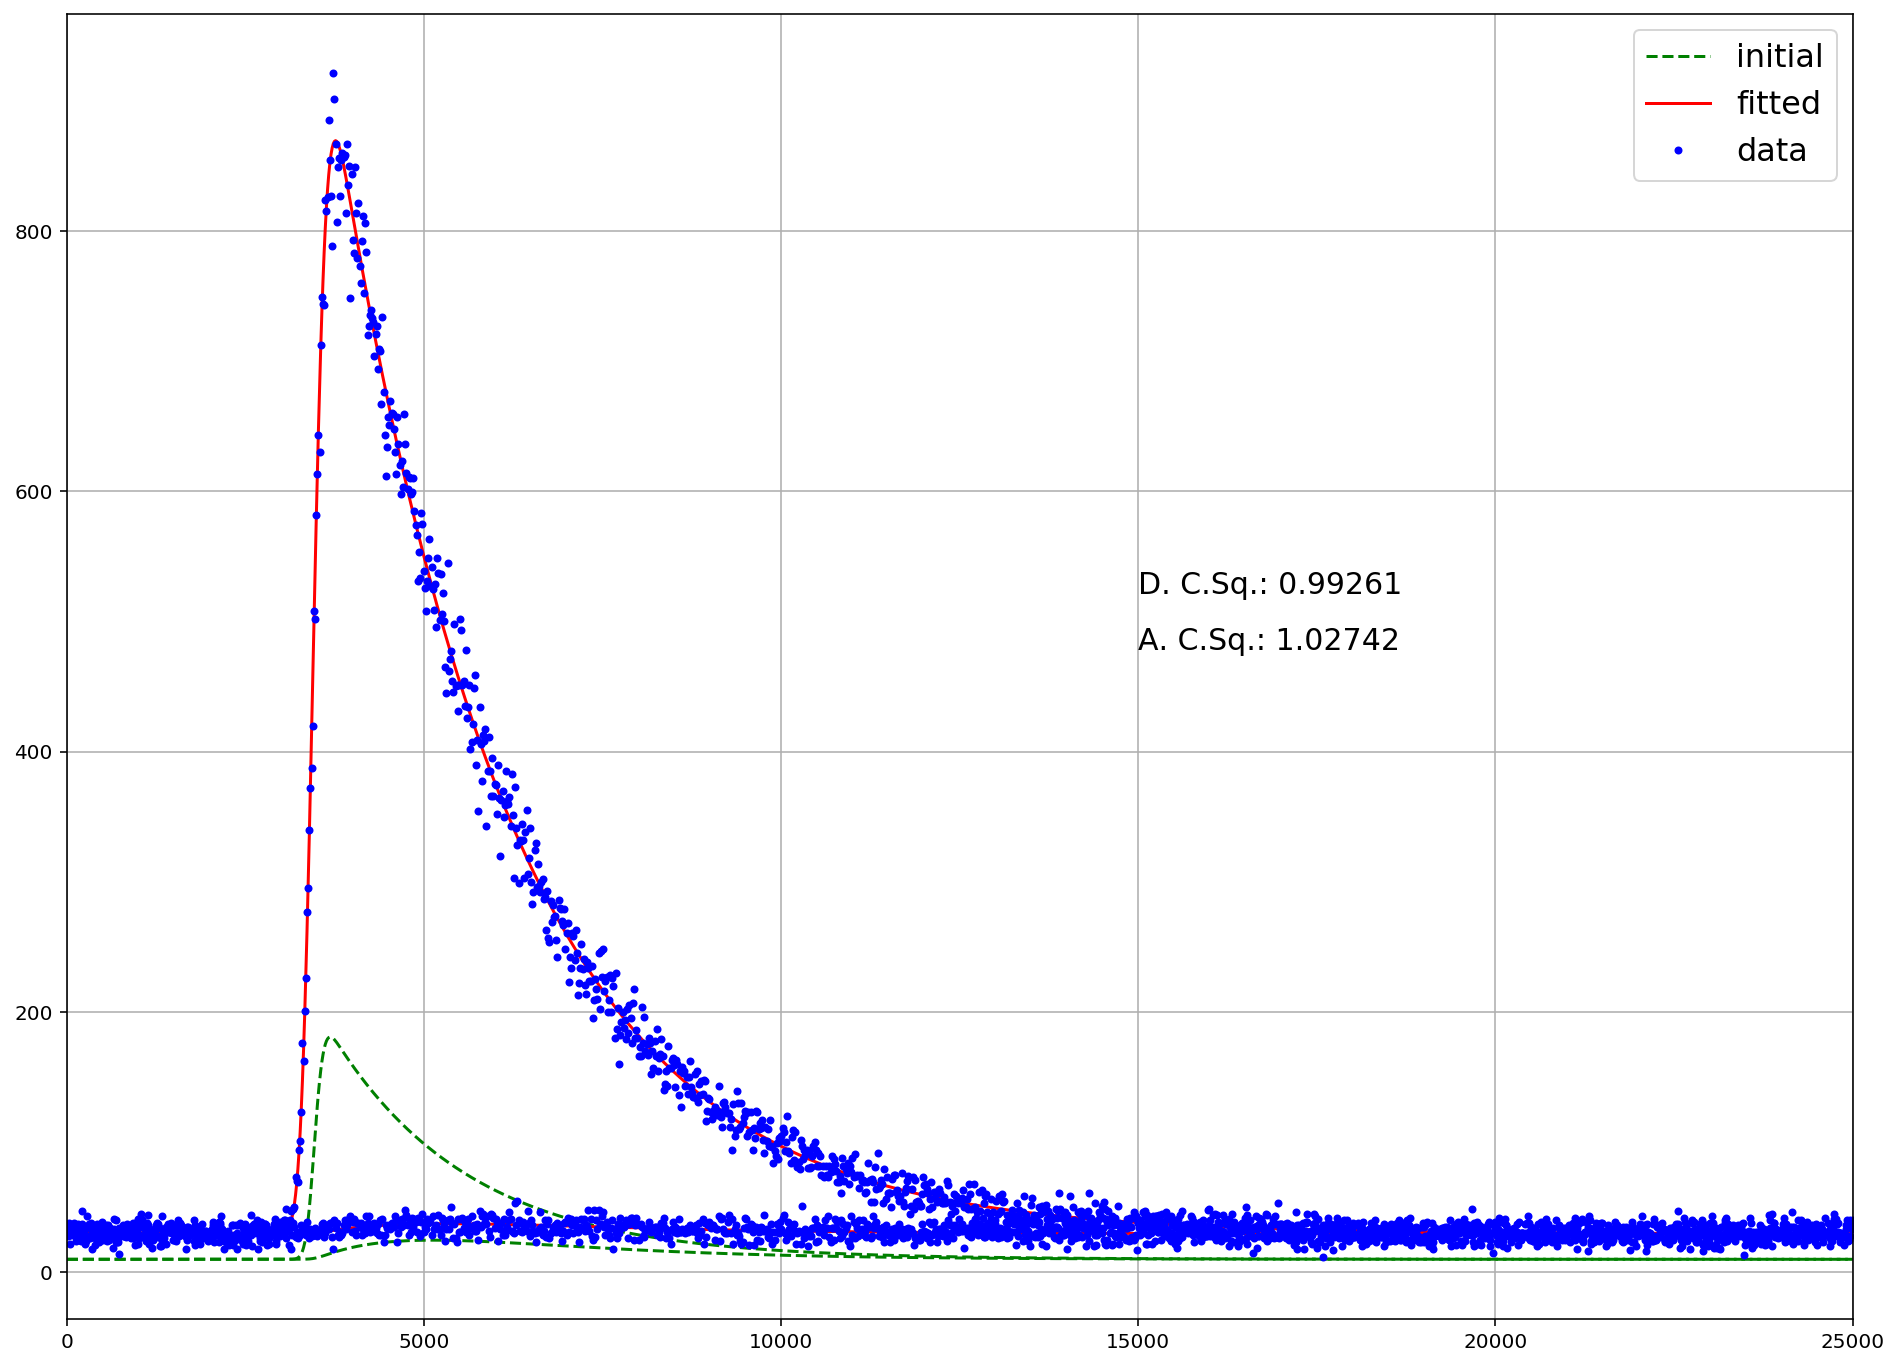

In [390]:
initial_guess = eval_ode(t, para_start, fitting = True)
fitted = eval_ode(t, fit.x, fitting = True)

# Getting red. chi-squared values for both curves
red_chi = calculate_chi_squred(
    data = sim_data,
    fit = fitted,
    number_fit_parameters = len(para_start)
)

plt.plot(t, initial_guess[:, 1],  'g--', label = 'initial')
plt.plot(t, initial_guess[:, 3],  'g--', )
plt.plot(t, fitted[:, 1],  'r-', label = 'fitted')
plt.plot(t, fitted[:, 3],  'r-')
plt.plot(t, sim_data[:, 1],  'b.', label = 'data')
plt.plot(t, sim_data[:, 3],  'b.')
plt.xlim(0, 25000)
plt.yscale('linear')
plt.legend(loc = 'best')
plt.grid()
plt.text(15000, 0.6 * np.max(fitted[:, 1]),
        s = 'D. C.Sq.: ' + str(round(red_chi[0], 5)),
        fontsize = 15 
)
plt.text(15000, 0.55 * np.max(fitted[:, 1]),
        s = 'A. C.Sq.: ' + str(round(red_chi[1], 5)),
        fontsize = 15 
)
plt.show()

In [391]:
print("\tInput Parameters\t Fitted Parameters")
print("-----------------------------------------------------")
for i in range(0, len(para_names)):
    print(para_names[i],"\t\t", round(para_start[i], 6), "\t\t\t", round(fit['x'][i], 6))

	Input Parameters	 Fitted Parameters
-----------------------------------------------------
D(0) 		 300 			 1492.280382
D*(0) 		 0 			 1.0
A(0) 		 300 			 4238.88938
A*(0) 		 0 			 1.0
kf_D 		 0.000392 			 0.000397
k_r 		 0.000125 			 1.2e-05
kf_A 		 0.000704 			 0.000704
IRFsigma 		 100 			 144.955359
IRFmu 		 3500 			 3497.42765
IRFoffset 		 10 			 29.507806
acceptor_shift 		 0 			 0.0


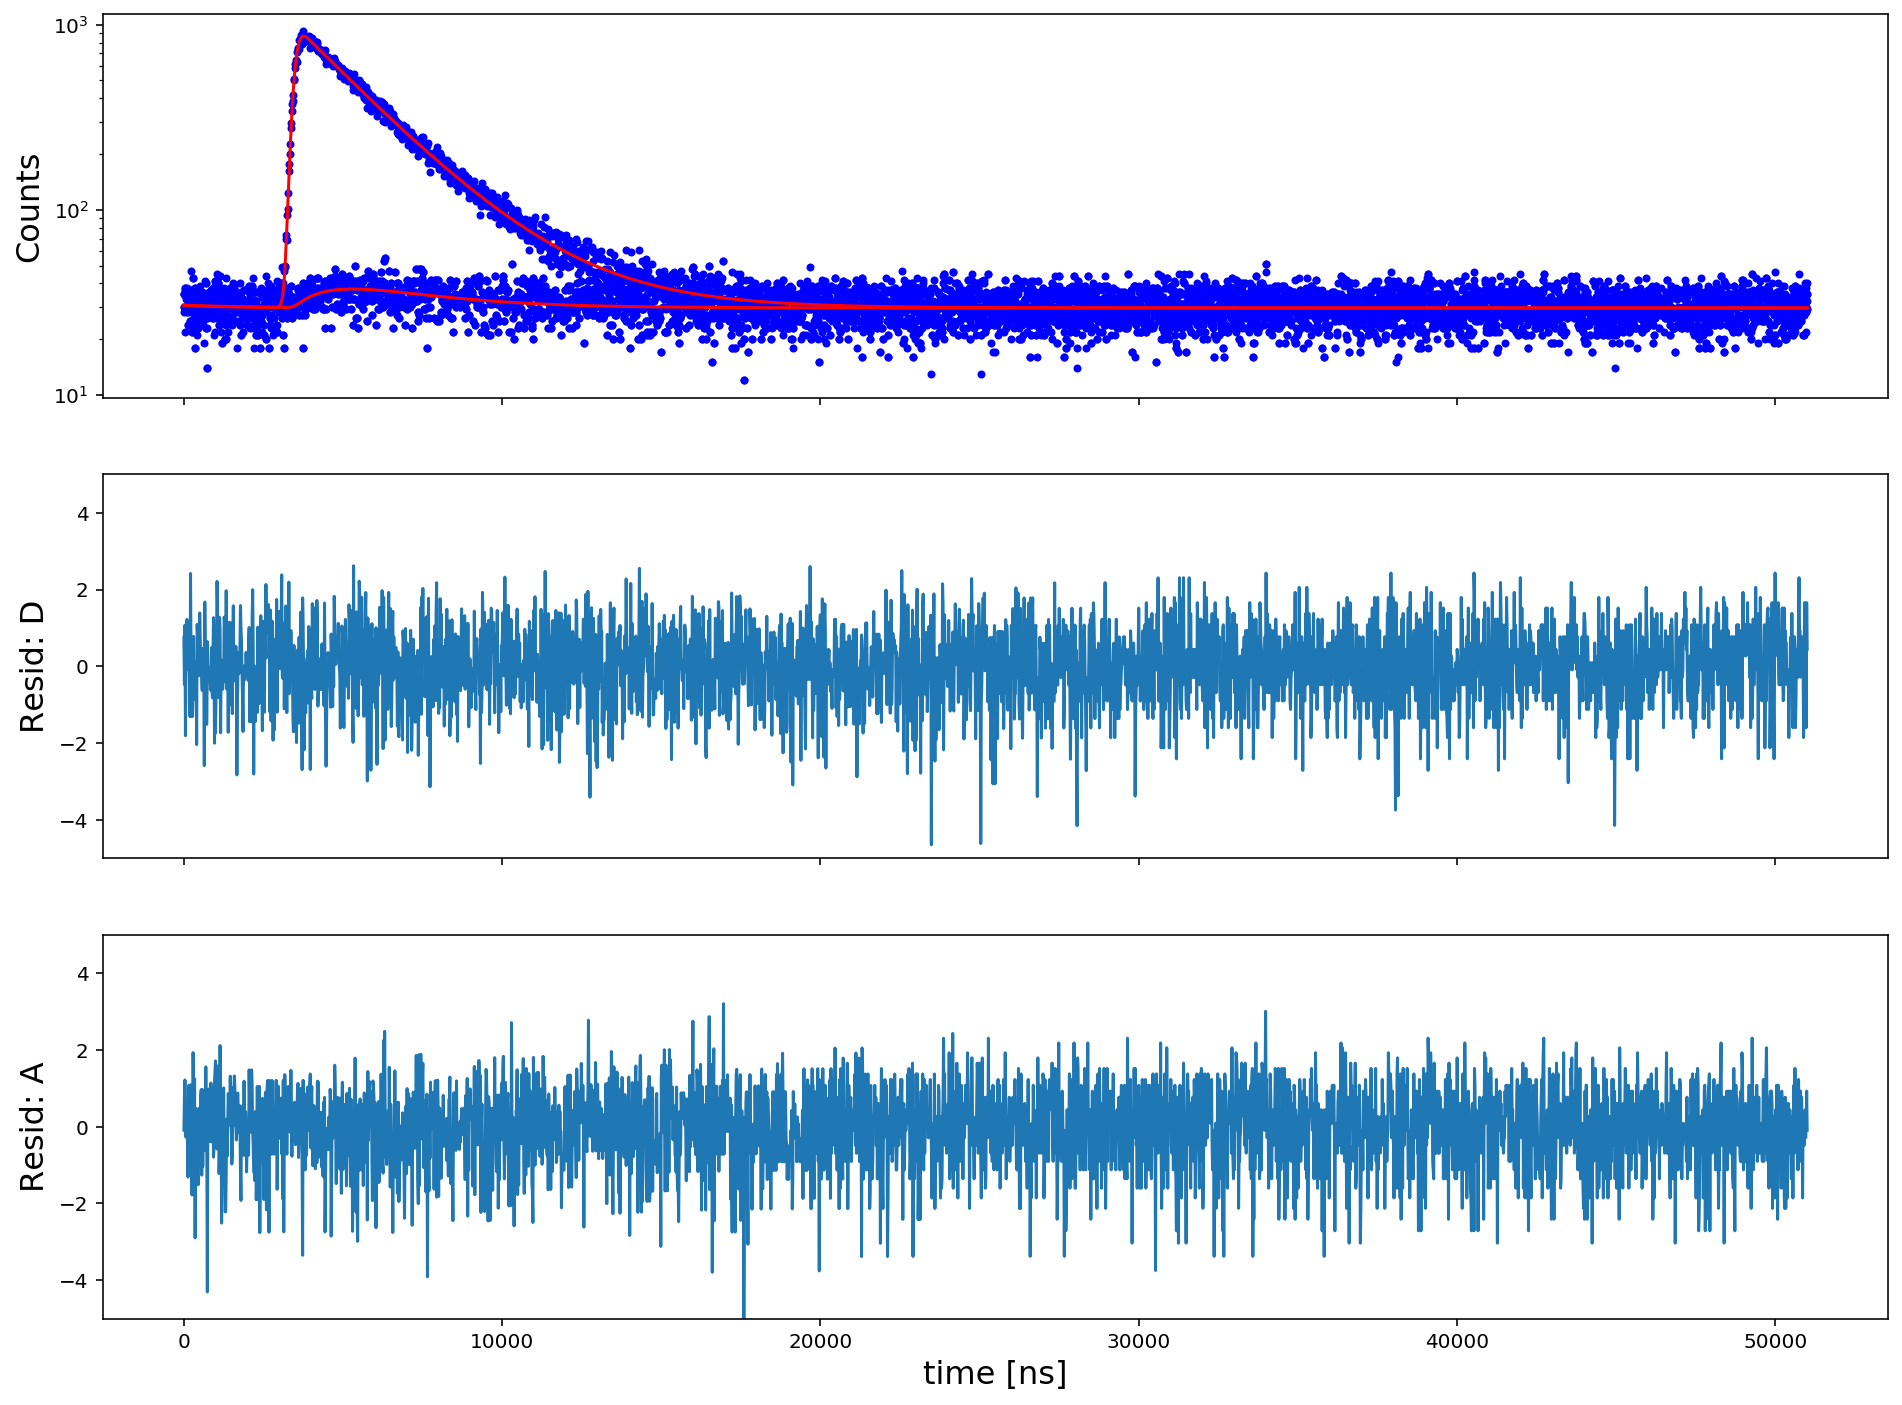

In [392]:
fig, ax = plt.subplots(3, 1, sharex = True)
ax[0].plot(t, sim_data[:, 1], 'b.', label = 'data')
ax[0].plot(t, sim_data[:, 3], 'b.')
ax[0].plot(t, sim_data[:, 3], 'b.')
ax[0].plot(t, fitted[:, 1], 'r-', label = 'fitted')
ax[0].plot(t, fitted[:, 3], 'r-')
ax[0].set(yscale = 'log', ylabel = 'Counts')
ax[2].set(xlabel = 'time [ns]')
ax[1].plot(t, (sim_data[:, 1] - fitted[:, 1])*1/np.sqrt(sim_data[:, 1]), '-')
ax[1].set(ylabel = 'Resid: D', ylim = (-5, 5))
ax[2].plot(t, (sim_data[:, 3] - fitted[:, 3])**1/np.sqrt(sim_data[:, 3]), '-')
ax[2].set(ylabel = 'Resid: A', ylim = (-5, 5))
plt.show()

In [ ]:
#test = pq_decoding_functions.readPTUData("data/191221_MicroscopeBenchmark_with_FPs.sptw/TCSPC_Benchmark_EGFP_NF488_14/TCSPC_Benchmark_EGFP_NF488_14_1.ptu")
